Objective: Investigate whether factor such as population, literacy religion, and other country characteristics are associated with GDP per capita

# Countries GDP Analysis 
Objectif of this project his to analyze different countries charateristics and investigate which factor may be associated with GDP per capita.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
import pandas as pd
data = pd.read_csv ('countries-GDP-Data.csv', decimal=',' )

In [24]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

Visualize the data

In [11]:
data.head()

,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
0,Afghanistan,ASIA (EX. NEAR EAST),31056997,647500,48.0,0.00,23.06,163.07,700.0,36.0,3.2,12.13,0.22,87.65,1.0,46.60,20.34,0.380,0.240,0.380
1,Albania,EASTERN EUROPE,3581655,28748,124.6,1.26,-4.93,21.52,4500.0,86.5,71.2,21.09,4.42,74.49,3.0,15.11,5.22,0.232,0.188,0.579
2,Algeria,NORTHERN AFRICA,32930091,2381740,13.8,0.04,-0.39,31.00,6000.0,70.0,78.1,3.22,0.25,96.53,1.0,17.14,4.61,0.101,0.600,0.298
3,American Samoa,OCEANIA,57794,199,290.4,58.29,-20.71,9.27,8000.0,97.0,259.5,10.00,15.00,75.00,2.0,22.46,3.27,NaN,NaN,NaN
4,Andorra,WESTERN EUROPE,71201,468,152.1,0.00,6.60,4.05,19000.0,100.0,497.2,2.22,0.00,97.78,3.0,8.71,6.25,NaN,NaN,NaN


In [4]:
data.shape

(227, 20)

In [12]:
#Checking the missing value 
data.isnull().sum()

Country                                0
Region                                 0
Population                             0
Area (sq. mi.)                         0
Pop. Density (per sq. mi.)             0
Coastline (coast/area ratio)           0
Net migration                          3
Infant mortality (per 1000 births)     3
GDP ($ per capita)                     1
Literacy (%)                          18
Phones (per 1000)                      4
Arable (%)                             2
Crops (%)                              2
Other (%)                              2
Climate                               22
Birthrate                              3
Deathrate                              4
Agriculture                           15
Industry                              16
Service                               15
dtype: int64

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Country                             227 non-null    str    
 1   Region                              227 non-null    str    
 2   Population                          227 non-null    int64  
 3   Area (sq. mi.)                      227 non-null    int64  
 4   Pop. Density (per sq. mi.)          227 non-null    str    
 5   Coastline (coast/area ratio)        227 non-null    str    
 6   Net migration                       224 non-null    str    
 7   Infant mortality (per 1000 births)  224 non-null    str    
 8   GDP ($ per capita)                  226 non-null    float64
 9   Literacy (%)                        209 non-null    str    
 10  Phones (per 1000)                   223 non-null    str    
 11  Arable (%)                          225 non-null    str 

In [8]:
data ['GDP ($ per capita)'].describe ()

count      226.000000
mean      9689.823009
std      10049.138513
min        500.000000
25%       1900.000000
50%       5550.000000
75%      15700.000000
max      55100.000000
Name: GDP ($ per capita), dtype: float64

In [9]:
data.describe()

,Population,Area (sq. mi.),GDP ($ per capita)
count,2.270000e+02,2.270000e+02,226.000000
mean,2.874028e+07,5.982270e+05,9689.823009
std,1.178913e+08,1.790282e+06,10049.138513
min,7.026000e+03,2.000000e+00,500.000000
25%,4.376240e+05,4.647500e+03,1900.000000
50%,4.786994e+06,8.660000e+04,5550.000000
75%,1.749777e+07,4.418110e+05,15700.000000
max,1.313974e+09,1.707520e+07,55100.000000


## Data preprocessing
I notice tha there is some missing value in this data so i just fill the misssing data useing the median of region that all countries belong to a countries that are closly geologically are often similar in many ways 

In [13]:
data.groupby('Region')[['GDP ($ per capita)','Literacy (%)','Agriculture']].median()

,GDP ($ per capita),Literacy (%),Agriculture
Region,,,
ASIA (EX. NEAR EAST),3450.0,90.60,0.1610
BALTICS,11400.0,99.80,0.0400
C.W. OF IND. STATES,3450.0,99.05,0.1980
EASTERN EUROPE,9100.0,98.60,0.0815
LATIN AMER. & CARIB,6300.0,94.05,0.0700
NEAR EAST,9250.0,83.00,0.0350
NORTHERN AFRICA,6000.0,70.00,0.1320
NORTHERN AMERICA,29800.0,97.50,0.0100
OCEANIA,5000.0,95.00,0.1505


In [14]:
# Fill up missing values
for col in data.columns.values:
    if data[col].isnull().sum() == 0:
        continue
    if col == 'Climate':
        guess_values = data.groupby('Region')['Climate'].apply(lambda x: x.mode().max())
    else:
        guess_values = data.groupby('Region')[col].median()
    for region in data['Region'].unique():
        data[col].loc[(data[col].isnull())&(data['Region']==region)] = guess_values[region]

C:\Users\olgak\AppData\Local\Temp\ipykernel_37712\362548483.py:10: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  data[col].loc[(data[col].isnull())&(data['Region']==region)] = guess_values[region]
C:\Users\olgak\AppData\Local\Temp\ipykernel_37712\362548483.py:10: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on wh

## Data Exploration
# Now we Find  10 Countries With  Highest GDP

In [16]:
import seaborn as sns

C:\Users\olgak\AppData\Local\Temp\ipykernel_37712\2834683857.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=countries_with_high_GDP,x="Country",y="GDP ($ per capita)",palette='Set3')


<Axes: xlabel='Country', ylabel='GDP ($ per capita)'>

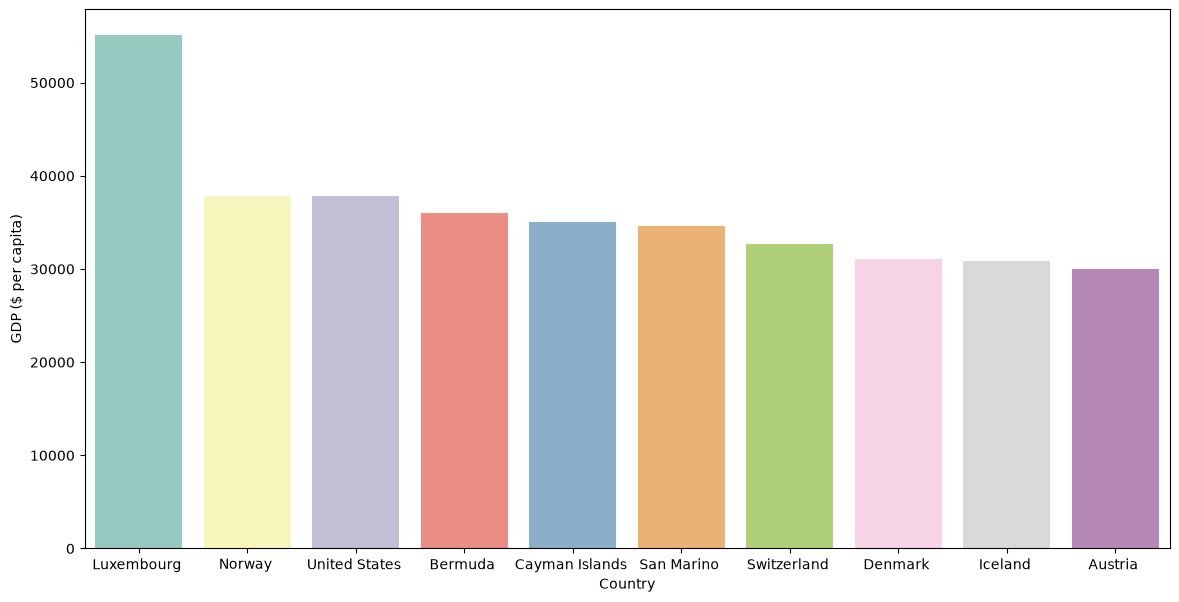

In [17]:
countries_with_highest_GDP=data.sort_values('GDP ($ per capita)',ascending=False)
countries_with_high_GDP=countries_with_highest_GDP[['GDP ($ per capita)','Country']].head(10)
plt.figure(figsize=(14,7))
sns.barplot(data=countries_with_high_GDP,x="Country",y="GDP ($ per capita)",palette='Set3')

# Now We Chek top factor that affecting GDP

Now we pick the six column which  are highly corelated  to  GDP and make scatter plot  so  first we cheak coorelation between all numerical columns with heatmap 

[]

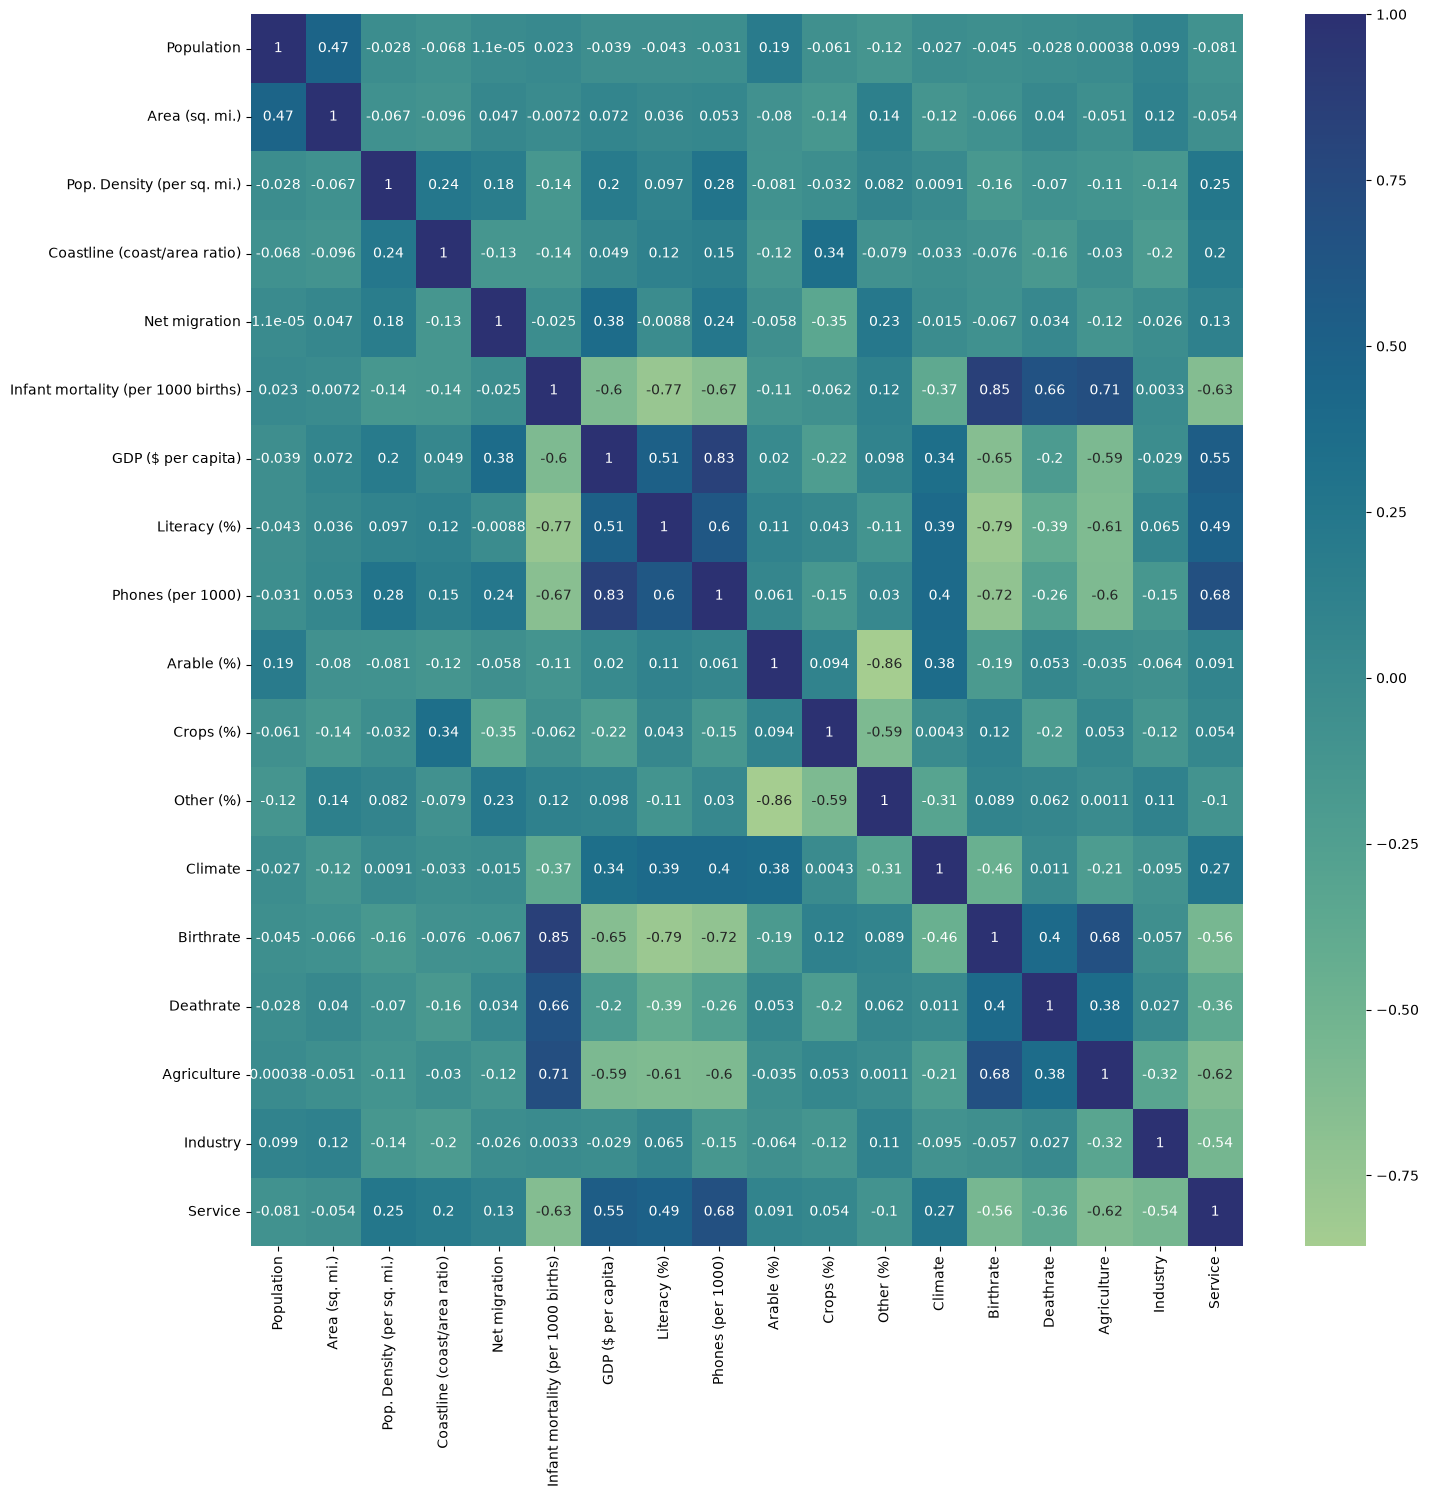

In [18]:
plt.figure(figsize=(16,16))
sns.heatmap(data.drop(columns=['Country','Region']).corr(),annot=True,cmap='crest')
plt.plot()

In [19]:
numeric_columns=data.drop(columns=['Country','Region'])
numeric_columns

,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
0,31056997,647500,48.0,0.00,23.06,163.07,700.0,36.0,3.2,12.13,0.22,87.65,1.0,46.60,20.34,0.380,0.240,0.380
1,3581655,28748,124.6,1.26,-4.93,21.52,4500.0,86.5,71.2,21.09,4.42,74.49,3.0,15.11,5.22,0.232,0.188,0.579
2,32930091,2381740,13.8,0.04,-0.39,31.00,6000.0,70.0,78.1,3.22,0.25,96.53,1.0,17.14,4.61,0.101,0.600,0.298
3,57794,199,290.4,58.29,-20.71,9.27,8000.0,97.0,259.5,10.00,15.00,75.00,2.0,22.46,3.27,NaN,NaN,NaN
4,71201,468,152.1,0.00,6.60,4.05,19000.0,100.0,497.2,2.22,0.00,97.78,3.0,8.71,6.25,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222,2460492,5860,419.9,0.00,2.98,19.62,800.0,NaN,145.2,16.90,18.97,64.13,3.0,31.67,3.92,0.090,0.280,0.630
223,273008,266000,1.0,0.42,NaN,NaN,NaN,NaN,NaN,0.02,0.00,99.98,1.0,NaN,NaN,NaN,NaN,0.400
224,21456188,527970,40.6,0.36,0.00,61.50,800.0,50.2,37.2,2.78,0.24,96.98,1.0,42.89,8.30,0.135,0.472,0.393
225,11502010,752614,15.3,0.00,0.00,88.29,800.0,80.6,8.2,7.08,0.03,92.90,2.0,41.00,19.93,0.220,0.290,0.489


# Modeling
training  and testing firstly i label encodeing all the feature  and i will use all the feature engenering  of data 

In [22]:
le=LabelEncoder()
data['Region_label']=le.fit_transform(data['Region'])
data['climate_label']=le.fit_transform(data['Climate'])
data.head(2)

,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),...,Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service,Region_label,climate_label
0,Afghanistan,ASIA (EX. NEAR EAST),31056997,647500,48.0,0.00,23.06,163.07,700.0,36.0,...,0.22,87.65,1.0,46.60,20.34,0.380,0.240,0.380,0,0
1,Albania,EASTERN EUROPE,3581655,28748,124.6,1.26,-4.93,21.52,4500.0,86.5,...,4.42,74.49,3.0,15.11,5.22,0.232,0.188,0.579,3,4


In [25]:
x=data.drop(columns=['Country','Region','GDP ($ per capita)'])
y=data['GDP ($ per capita)']

#splitb the data for train and test 
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)
#cheaking shape 
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((181, 19), (46, 19), (181,), (46,))

# Total GDP

In [27]:
data['Total GDP_capita']=data['GDP ($ per capita)']*data['Population']
top_gdp_countries=data.sort_values('Total GDP_capita',ascending=False).head(10)

In [29]:
other = pd.DataFrame({'Country':['Other'], 'Total GDP_capita':[data['Total GDP_capita'].sum() - top_gdp_countries['Total GDP_capita'].sum()]})
gdps = pd.concat([top_gdp_countries[['Country','Total GDP_capita']],other],ignore_index=True)

In [30]:
gdps

,Country,Total GDP_capita
0,United States,1.128119e+13
1,China,6.569869e+12
2,Japan,3.594474e+12
3,India,3.176521e+12
4,Germany,2.274855e+12
5,France,1.680181e+12
6,United Kingdom,1.678874e+12
7,Italy,1.552165e+12
8,Brazil,1.429395e+12
9,Russia,1.271753e+12


In [31]:
other

,Country,Total GDP_capita
0,Other,1.820072e+13


C:\Users\olgak\AppData\Local\Temp\ipykernel_37712\1172417550.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Country',y='Total GDP_capita',data=gdps,palette='Set3')


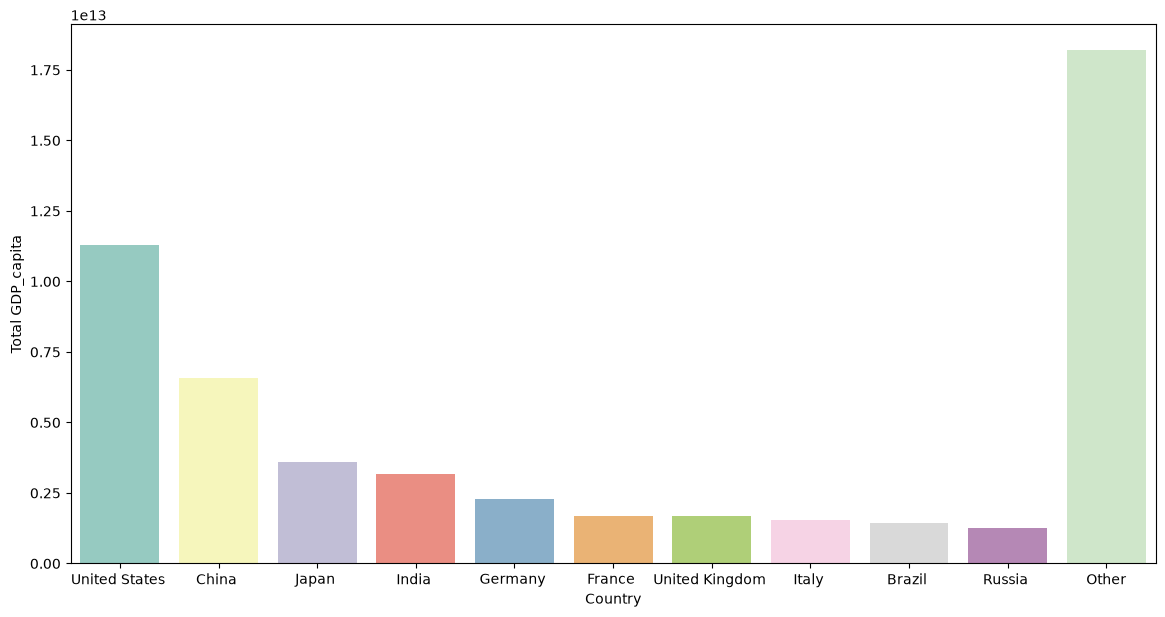

In [32]:
plt.figure(figsize=(14,7))
sns.barplot(x='Country',y='Total GDP_capita',data=gdps,palette='Set3')
plt.show()

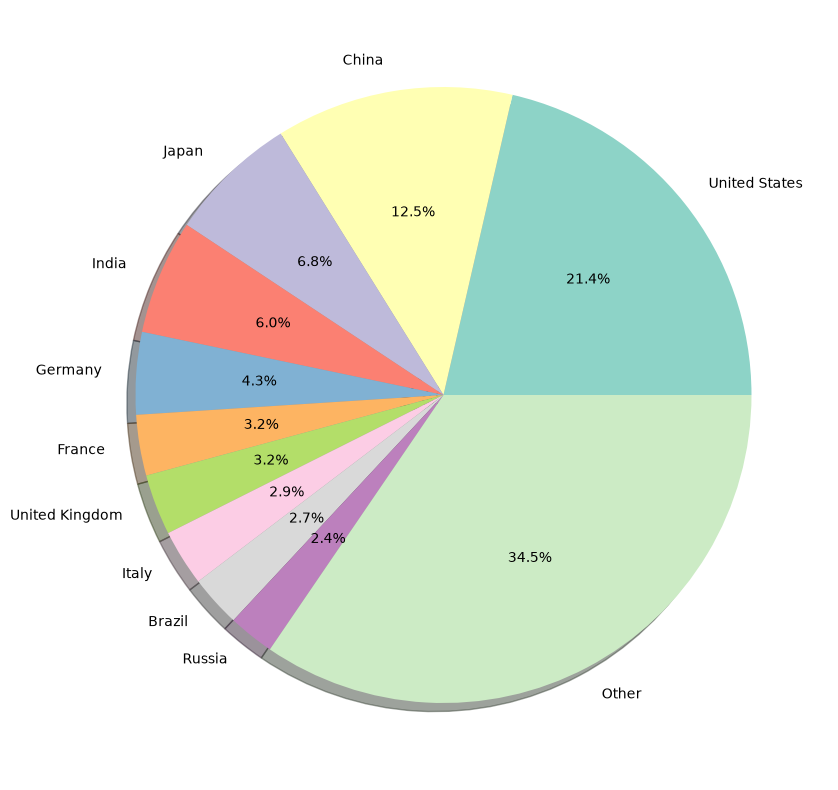

In [33]:
plt.figure(figsize=(10,10))
plt.pie(gdps['Total GDP_capita'],labels=gdps['Country'],colors=sns.color_palette("Set3", gdps.shape[0]).as_hex(),autopct='%1.1f%%',shadow=True)


now let us cheak the  factor effecting gdp
so we cheak the correlation between total gdp and other colums

In [38]:
corr_to_gdp= pd.Series()
for col in data.drop(columns=['Country','Region']):
  if ((col!='Total_GDP ($)')&(col!='Climate')&(col!='GDP ($ per capita)')):
        corr_to_gdp[col] = data['Total GDP_capita'].corr(data[col])
abs_corr_to_gdp=corr_to_gdp.abs().sort_values(ascending=False)
corr_to_gdp=corr_to_gdp.loc[abs_corr_to_gdp.index]
print(corr_to_gdp)

Total GDP_capita                      1.000000
Population                            0.639435
Area (sq. mi.)                        0.556312
Phones (per 1000)                     0.232506
Birthrate                            -0.168497
Agriculture                          -0.146380
Arable (%)                            0.128978
Infant mortality (per 1000 births)   -0.123894
Literacy (%)                          0.110977
Service                               0.094829
climate_label                         0.084716
Region_label                         -0.079671
Crops (%)                            -0.078896
Coastline (coast/area ratio)         -0.065539
Other (%)                            -0.063273
Net migration                         0.054543
Industry                              0.043278
Deathrate                            -0.038199
Pop. Density (per sq. mi.)           -0.028738
dtype: float64


## Finally let us do comparision of economy structure of 10 countries  with highest GDP

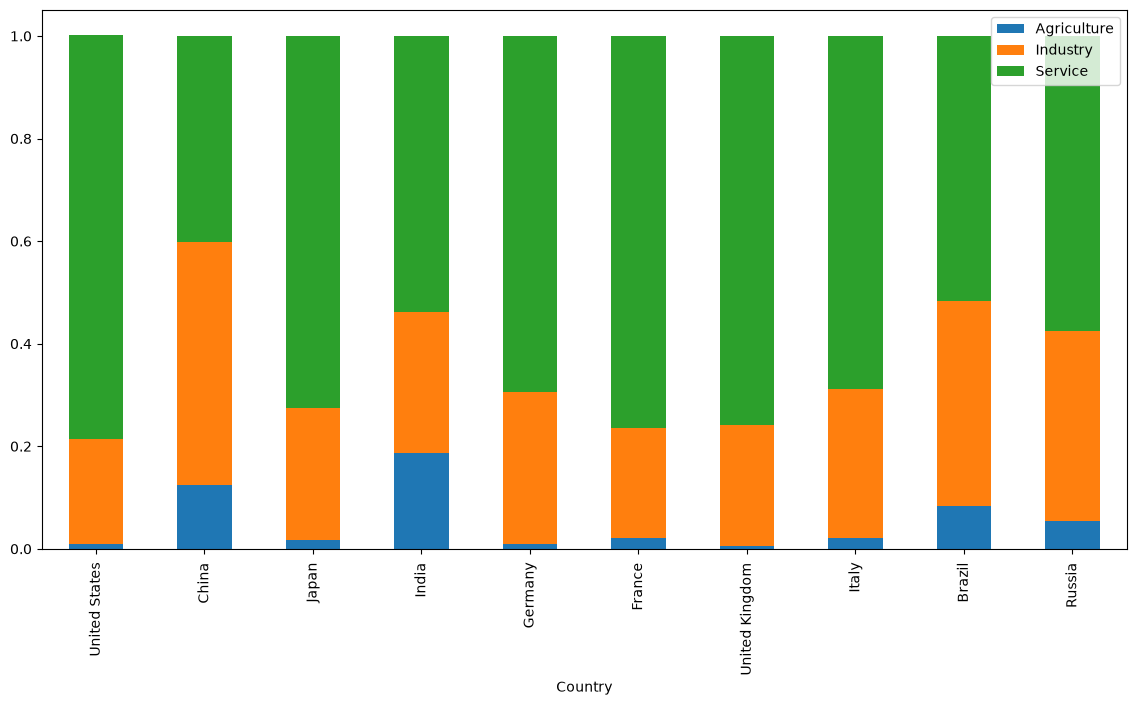

In [39]:
plot_data=top_gdp_countries[['Country','Agriculture', 'Industry', 'Service']].set_index('Country')
plot_data.plot.bar(stacked=True,figsize=(14,7))
plt.show()

CONCLUSION
The analysis shows that GDP varies significantly across countries.The United States and China have some of the largest total GDP values, while population and country size show the strongest positive correlations with total GDP in this dataset. The analysis also shows that the economies of the top-GDP countries rely largely on the service and industry sectors, while agriculture generally represents a smaller share.
Overall, GDP is associated with several demographic and economic factors rather than one factor alone.